/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


ANN Evaluation on Liver Dataset

Accuracy: 0.7607

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.63      0.58        30
           1       0.86      0.80      0.83        87

    accuracy                           0.76       117
   macro avg       0.70      0.72      0.70       117
weighted avg       0.78      0.76      0.77       117



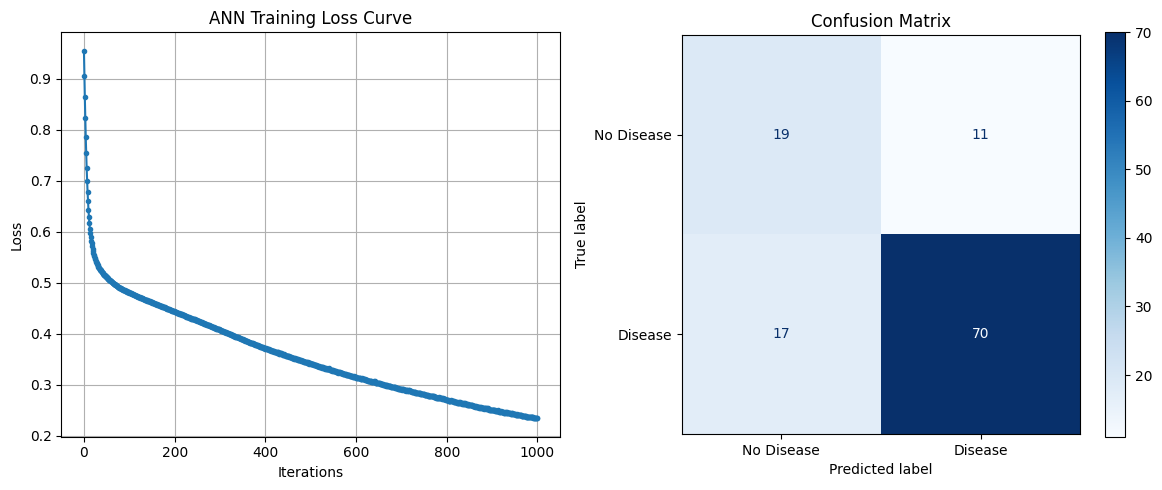

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# ==========================================
# 1. Load and Preprocess Dataset
# ==========================================
df = pd.read_csv("/content/sample_data/Indian Liver Patient Dataset (ILPD).csv")

# Encode Gender (Male=1, Female=0)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Handle missing values in 'A/G Ratio'
df = df.fillna(df.mean())

# Separate Features (X) and Target (y)
X = df.drop('Selector', axis=1)
# Original Selector: 1=Liver Patient, 2=Not a Liver Patient. Convert to 1 and 0.
y = df['Selector'].apply(lambda x: 1 if x == 1 else 0)

# ==========================================
# 2. Data Splitting and Scaling
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. Build and Train ANN
# ==========================================
ann = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)
ann.fit(X_train_scaled, y_train)

# ==========================================
# 4. Predictions and Evaluation
# ==========================================
y_pred = ann.predict(X_test_scaled)

print("ANN Evaluation on Liver Dataset\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# 5. Visualizations
# ==========================================
plt.figure(figsize=(12, 5))

# Plot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(ann.loss_curve_, marker='.', linestyle='-')
plt.title("ANN Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)

# Plot 2: Confusion Matrix
plt.subplot(1, 2, 2)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Disease', 'Disease'], cmap='Blues', ax=plt.gca())
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()